# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div style="background-color:#f1be3e">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           X          |
|------------|----------------------|
| Student A  |        XXXXXXX       |
| Student B  |        XXXXXXX       |
| Student C  |        XXXXXXX       |
| Student D  |        XXXXXXX       |

#### Imports

In [190]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action

In [191]:
np.random.seed(0)

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [211]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def random(self, agent: Agent, maze: Maze) -> Action:
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        pos_acts = agent.get_valid_actions(maze)
        act = np.random.choice(pos_acts)
        return act

    def e_greedy(self, agent: Agent,  maze: Maze, eps: float) -> Action:
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """
        # Determine the action with highest reward and choose with probability 1 - eps
        # Choose random action with probability eps
        curr_state = agent.get_state(maze)
        pos_act = agent.get_valid_actions(maze)
        qs = np.empty(len(pos_act), dtype=np.float64)

        for i in range(len(pos_act)):
            qs[i] = self.q_table.get_q(curr_state, pos_act[i])
        chance = np.random.random()
        high_q_idx =  qs.argmax()
        if chance < eps:
            return np.random.choice(pos_act)
        else:
            return pos_act[high_q_idx]

    def boltzmann(self, agent: Agent, maze: Maze, temperature: float) -> Action:
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """
        temperature = max(temperature, 1e-9)

        curr_state = agent.get_state(maze)
        pos_act = agent.get_valid_actions(maze)
        qs = np.array([self.q_table.get_q(curr_state, act) for act in pos_act])

        exp_qs = np.exp((qs - np.max(qs)) / temperature)

        sum_exp_qs = np.sum(exp_qs)

        probs = exp_qs / sum_exp_qs

        action = np.random.choice(pos_act, p=probs)
        return action


<div style="background-color:#f1be3e">

_Put your extra code blocks above (if any) and write your answer here._

#### Question 2

In [193]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=24, y=14, reward=10)
maze.set_terminal(x=24, y=14)
# Create an Agent.
agent = Agent(start_x=0, start_y=0)
# Create a QTable.
states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)

# Hyper-parameters.
n_episodes = 300
episode_lengths = []
episode_rewards = []

for episode in tqdm(range(n_episodes)):
    pass

100%|██████████| 300/300 [00:00<00:00, 262526.85it/s]


In [194]:
# Create maze instances
# Toy Maze
maze_toy = Maze("./../data/toy_maze.txt")
maze_toy.set_reward(x=9, y=9, reward=10)
maze_toy.set_terminal(x=9, y=9)

# Easy Maze
maze_easy = Maze("./../data/easy_maze.txt")
maze_easy.set_reward(x=24, y=14, reward=10)
maze_easy.set_terminal(x=24, y=14)

In [195]:
class QLearning:
    pass
class SARSA:
    pass

In [210]:
def step(
        agent:Agent,
        maze: Maze,
        q_table: QTable,
        exploration_strategy: ExplorationStrategy,
        exploration_strategy_name: str,
        learner: QLearning | SARSA = None,
        epsilon = 0.05,
        temperature = 1.0,
        step_penalty = 0.01):
    """Take a single step and update the Q-table accordingly.
    
    :param agent: Agnet instance
    :param maze: Maze instance
    :param q_table: QTable instance
    :param exploration_strategy: ExplorationStrategy instance
    :param exploration_strategy_name: Name of the exploration strategy to use, one of "random", "e_greedy", "boltzmann"
    :param learner: QLearning or SARSA instance
    :param epsilon: Exploration parameter for epsilon-greedy strategy
    :param temperature: Temperature parameter for Boltzmann strategy
    :param step_penalty: Small shaping penalty applied per non-terminal step

    :return:
    - reward: Reward received after taking the action
    - done: Whether the episode has terminated after taking the action

    :raises Value:Error: If an invalid exploration is not provided or recongnised
    """

    # percept state
    state = agent.get_state(maze)

    # Choose action
    action_to_take = None
    if exploration_strategy_name == "random":
        action_to_take = exploration_strategy.random(agent, maze)
    elif exploration_strategy_name == "e_greedy":
        # Eps value close to zero favours exploitation, while a value close to 1 favours exploration.
        action_to_take = exploration_strategy.e_greedy(agent, maze, eps=epsilon)
        # print(f"Taking action: {action_to_take}")
    elif exploration_strategy_name == "boltzmann":
        action_to_take = exploration_strategy.boltzmann(agent, maze, temperature)
    else:
        raise ValueError(f"Invalid exploration strategy method: {exploration_strategy_name}")
    
    # Execute action and get feedback
    next_state, reward, done = agent.step(action_to_take, maze)
    if not done:
        # Shaping: encourage shorter paths with a small step penalty.
        reward -= step_penalty

    # Update Q-table
    if isinstance(learner, QLearning):
        learner.learn(agent.get_valid_actions(maze), state, action_to_take, next_state, reward, done)


    elif isinstance(learner, SARSA):
        if agent.nr_of_actions_since_reset > 1:
            prev_state = learner.get_last_state()       # Get previous state
            prev_action = learner.get_last_action()     # Get previous action
            prev_reward = learner.get_last_reward()     # Get previous reward
            prev_done = learner.get_last_done()         # Get previous done
            learner.learn(state=prev_state, action=prev_action, next_state=state, next_action=action_to_take, reward=prev_reward, done=prev_done)        
        
            if done:
                learner.learn(state=state, action=action_to_take, next_state=None, next_action=None, reward=reward, done=done)

        learner.set_last_state(state)
        learner.set_last_action(action_to_take)
        learner.set_last_reward(reward)
        learner.set_last_done(done)

    else:
        # Entry Q(s, a) stores the q-value for taking action a in state s
        q_table.set_q(state, action_to_take, reward)

    return reward, done

In [197]:
def epsiodic_cycle(
        agent: Agent,
        maze: Maze, 
        q_table: QTable, 
        exploration_strategy: ExplorationStrategy, 
        exploration_strategy_name: str,
        learner: QLearning | SARSA = None,
        temperature = 1.0,
        remaining_steps = 0):
    
    reached_target = False
    episode_reward = 0

    while not reached_target and agent.nr_of_actions_since_reset <= remaining_steps:
        step_reward, step_done = step(agent, maze, q_table, exploration_strategy, exploration_strategy_name, learner, temperature=temperature)
        if step_done:
            reached_target = True
        
        episode_reward += step_reward
    
    return agent.nr_of_actions_since_reset, episode_reward

Until the target is reached or the number of steps does not exceed the maximum number of steps:
- Read the state
- Choose the next action based on the provided strategy
- Execute action and get feedback
- Update the Q-Table

#### Question 3

In [198]:
def run_episodes(agent: Agent, maze: Maze, q_table: QTable, exploration_strategy: ExplorationStrategy, exploration_strategy_name: str, n_episodes: int, learner: QLearning | SARSA = None, max_steps_per_episode: int = 30000):
    episode_lengths = []
    episode_rewards = []
    temperature = 1.0
    temperature_decay = 0.975

    for _ in range(n_episodes):
        agent.reset()

        current_episode_length, current_episode_reward = epsiodic_cycle(
            agent,
            maze,
            q_table,
            exploration_strategy,
            exploration_strategy_name,
            learner,
            temperature,
            max_steps_per_episode,
        )

        if exploration_strategy_name == "boltzmann":
            temperature *= temperature_decay

        episode_lengths.append(current_episode_length)
        episode_rewards.append(current_episode_reward)

    return episode_lengths, episode_rewards

Only run another episodic cycle so long as the total number of steps is less than the stopping criterion. It also stops if it exceeds the number of maximum steops. In case the last one does not end by finding the target, it will have one extra step resulting in it not being used, so that one canceled cycle with few steps won't be taken into account.

#### Question 4

In [199]:
maze = Maze("./../data/toy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)

agent = Agent(start_x=0, start_y=0)

states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
exploration_strategy = ExplorationStrategy(q_table)

n_episodes = 300
max_steps_per_episode = 30000
np.random.seed(100)
episode_lengths, episode_rewards = run_episodes(
    agent,
    maze,
    q_table,
    exploration_strategy,
    "random",
    n_episodes,
    max_steps_per_episode=max_steps_per_episode,
 )

print(f"Total number of steps taken: {np.sum(episode_lengths)}")
print(f"Total number of episodes: {len(episode_lengths)}")

print(f"Steps per episode: {episode_lengths}")
print(f"Steps per epsiode (mean): {np.round(np.mean(episode_lengths), 2)}")

Total number of steps taken: 396994
Total number of episodes: 300
Steps per episode: [2662, 450, 1216, 684, 1076, 672, 484, 1400, 2036, 1008, 1666, 1710, 1956, 1604, 1330, 1172, 368, 1164, 2018, 1364, 688, 1236, 1572, 1038, 850, 566, 1592, 1998, 158, 1994, 396, 636, 1072, 416, 696, 352, 186, 2308, 1370, 386, 3008, 986, 3528, 644, 1410, 358, 2774, 2204, 262, 370, 126, 206, 188, 264, 1010, 954, 1996, 802, 238, 260, 204, 3592, 220, 1434, 246, 762, 2538, 356, 812, 826, 420, 3528, 540, 284, 728, 1008, 2570, 176, 1534, 1310, 1810, 420, 416, 778, 3650, 3560, 614, 1018, 424, 170, 448, 158, 8538, 1182, 1376, 1266, 2600, 564, 488, 484, 1284, 1078, 680, 3002, 642, 424, 3304, 2754, 3968, 2210, 2692, 662, 500, 1144, 1248, 144, 878, 336, 2568, 222, 2094, 372, 1904, 744, 2204, 166, 3044, 774, 892, 1596, 1488, 396, 1342, 1484, 376, 1716, 586, 86, 478, 512, 194, 618, 466, 544, 618, 1520, 1346, 1044, 726, 250, 1378, 536, 428, 1216, 274, 966, 3546, 1896, 2570, 1052, 2874, 1326, 468, 1010, 2480, 1182, 942

In [200]:
def plot_average_runs(runs_number: int, random_seeds: List[int], maze_name: str, n_episodes: int, exploration_strategy_name: str, learner_name: str = None, max_steps_per_episode: int = 30000):
    episodes_per_run = []
    maze = None

    if maze_name == "toy":
        maze = maze_toy
    elif maze_name == "easy":
        maze = maze_easy
    else:
        raise ValueError(f"Invalid maze name: {maze_name}")

    for i in range(runs_number):
        print(f"Run {i+1}/{runs_number} with random seed {random_seeds[i]}")
        agent = Agent(start_x=0, start_y=0)     # Creates the Agent
        states = maze.get_all_states()          # Creates the Maze
        actions = [Action(id) for id in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)       # Creates the Q-table
        exploration_strategy = ExplorationStrategy(q_table)

        params = {"lr": 0.7, "gamma": 0.9}
        learner = None
        if learner_name == "SARSA":
            learner = SARSA(q_table, params)    
        elif learner_name == "QLearning":
            learner = QLearning(q_table, params)

        np.random.seed(random_seeds[i])
        episode_lengths, episode_rewards = run_episodes(
            agent,
            maze,
            q_table,
            exploration_strategy,
            exploration_strategy_name,
            n_episodes,
            learner,
            max_steps_per_episode,
        )
        episodes_per_run.append(episode_lengths)
    
    shortest_run = len(min(episodes_per_run, key=len))
    episodes_per_run_shortest = [run[:shortest_run] for run in episodes_per_run]
    average_episodes = np.mean(episodes_per_run_shortest, axis=0)
    print(f"Shortest run has {shortest_run} episodes")

    plt.figure(figsize=(10, 6))
    plt.plot(np.arange(1, len(average_episodes) + 1, 1), average_episodes, marker='o', label=f"{exploration_strategy_name} {learner_name}")
    plt.title(f"Average number of steps per episode over {runs_number} runs for {exploration_strategy_name} {learner_name} in {maze_name} maze")
    plt.xticks(np.arange(1, len(average_episodes) + 1, 1))  # Display all episode numbers on the x-axis
    plt.xlabel("Episode")
    plt.ylabel("Average Number of Steps")
    plt.show()

In [218]:
def average_steps_per_episode(
    runs_number: int,
    random_seeds: List[int],
    maze_name: str,
    n_episodes: int,
    exploration_strategy_name: str,
    learner_name: str,
    max_steps_per_episode: int = 30000,
    ) -> np.ndarray:
    """Return average steps per episode across runs for a strategy/learner pair."""
    episodes_per_run = []
    if maze_name == "toy":
        maze = maze_toy
    elif maze_name == "easy":
        maze = maze_easy
    else:
        raise ValueError(f"Invalid maze name: {maze_name}")

    for i in range(runs_number):
        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(id) for id in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)

        params = {"lr": 0.7, "gamma": 0.9}
        if learner_name == "SARSA":
            learner = SARSA(q_table, params)
        elif learner_name == "QLearning":
            learner = QLearning(q_table, params)
        else:
            raise ValueError(f"Invalid learner name: {learner_name}")

        np.random.seed(random_seeds[i])
        episode_lengths, _ = run_episodes(
            agent,
            maze,
            q_table,
            exploration_strategy,
            exploration_strategy_name,
            n_episodes,
            learner,
            max_steps_per_episode,
        )
        episodes_per_run.append(episode_lengths)

    shortest_run = len(min(episodes_per_run, key=len))
    episodes_per_run_shortest = [run[:shortest_run] for run in episodes_per_run]
    return np.mean(episodes_per_run_shortest, axis=0)

Run 1/11 with random seed 7
Run 2/11 with random seed 3
Run 3/11 with random seed 6
Run 4/11 with random seed 4
Run 5/11 with random seed 0
Run 6/11 with random seed 5
Run 7/11 with random seed 2
Run 8/11 with random seed 8
Run 9/11 with random seed 9
Run 10/11 with random seed 1
Run 11/11 with random seed 10
Shortest run has 30 episodes


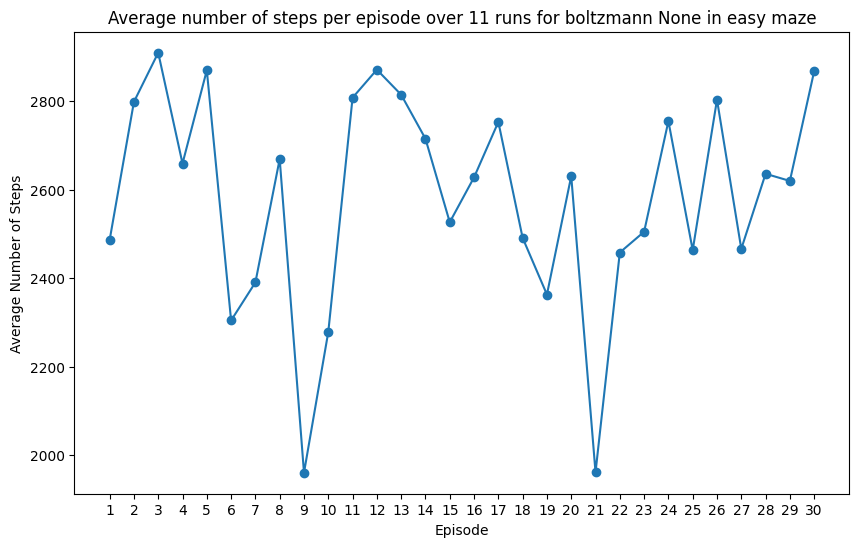

In [201]:
# Plotting the average number of steps per episode over 20 runs for the random exploration strategy in the toy maze
random_seeds = [7, 3, 6, 4, 0, 5, 2, 8, 9, 1, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=30,
    exploration_strategy_name="boltzmann",
    max_steps_per_episode=3000,
 )

20 Runs using the Boltzmann strategy:

Run 1/20 with random seed 1
Run 2/20 with random seed 2
Run 3/20 with random seed 3
Run 4/20 with random seed 4
Run 5/20 with random seed 5
Run 6/20 with random seed 6
Run 7/20 with random seed 7
Run 8/20 with random seed 8
Run 9/20 with random seed 9
Run 10/20 with random seed 10
Run 11/20 with random seed 11
Run 12/20 with random seed 12
Run 13/20 with random seed 13
Run 14/20 with random seed 14
Run 15/20 with random seed 15
Run 16/20 with random seed 16
Run 17/20 with random seed 17
Run 18/20 with random seed 18
Run 19/20 with random seed 19
Run 20/20 with random seed 20
Shortest run has 70 episodes


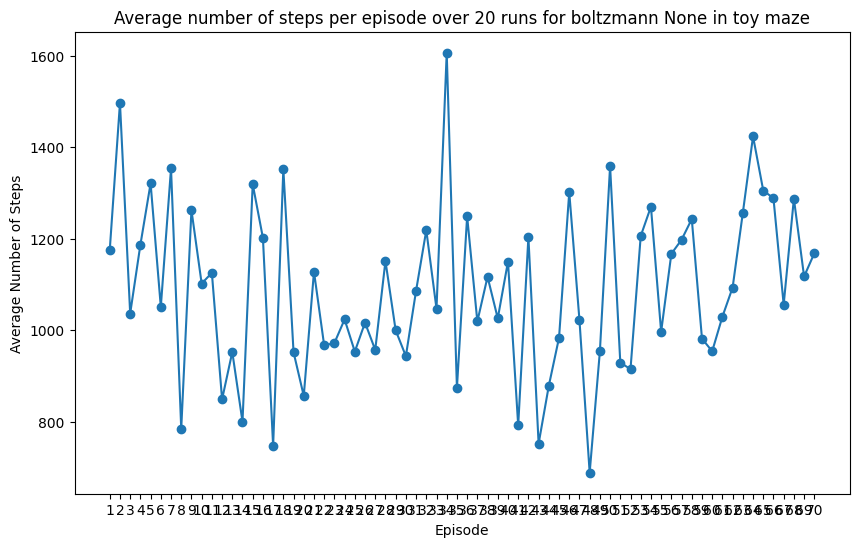

In [202]:
# Plotting the average number of steps per episode over 20 runs for the random exploration strategy in the toy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="toy",
    n_episodes=70,
    exploration_strategy_name="boltzmann",
    max_steps_per_episode=3000,
 )

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 5

In [203]:
class QLearning:
    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        q_value_prev = self.q_table.get_q(state, action)
        q_value_max = None

        if done:
            q_value_max = 0     # If last state, set max to 0
        else:
            # Get estimate for the next state q-value, action with best reward
            q_value_max = np.max([self.q_table.get_q(next_state, act) for act in possible_actions])

        q_value_new = q_value_prev + self.params["lr"] * (reward + (self.params["gamma"] * q_value_max) - q_value_prev)
        self.q_table.set_q(state, action, q_value_new)

In [204]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def get_last_state(self) -> State:
        return self.last_state

    def set_last_state(self, state: State) -> None:
        self.last_state = state
    
    def get_last_action(self) -> Action:
        return self.last_action
    
    def set_last_action(self, action: Action) -> None:
        self.last_action = action

    def get_last_reward(self) -> float:
        return self.last_reward
    
    def set_last_reward(self, reward: float) -> None:
        self.last_reward = reward

    def get_last_done(self) -> bool:
        return self.last_done
    
    def set_last_done(self, done: bool) -> None:
        self.last_done = done
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        q_value_prev = self.q_table.get_q(state, action)
        q_value_next = None
        if done:
            q_value_next = 0
        else:
            q_value_next = self.q_table.get_q(next_state, next_action)

        q_value_new = q_value_prev + self.params["lr"] * (reward + (self.params["gamma"] * q_value_next) - q_value_prev)
        self.q_table.set_q(state, action, q_value_new)

QLearning updates based on the following:
$$Q(s, a)_{new} = Q(s, a)_{old} + \alpha(r + \gamma Q(s^′, a_{max} ) −Q(s, a)_{old}) $$
And it is not influenced by the last selected option.

While SARSA updates based on the last transition (influenced by the last action):
$$ Q(s, a)_{new} = Q(s, a)_{old} + \alpha(r + \gamma Q(s^′, a^′) −Q(s, a)_{old}) $$

#### Question 6

Average 10 runs, QLearning, Random strategy (Toy Maze):

Run 1/10 with random seed 1
Run 2/10 with random seed 2
Run 3/10 with random seed 3
Run 4/10 with random seed 4
Run 5/10 with random seed 5
Run 6/10 with random seed 6
Run 7/10 with random seed 7
Run 8/10 with random seed 8
Run 9/10 with random seed 9
Run 10/10 with random seed 10
Shortest run has 100 episodes


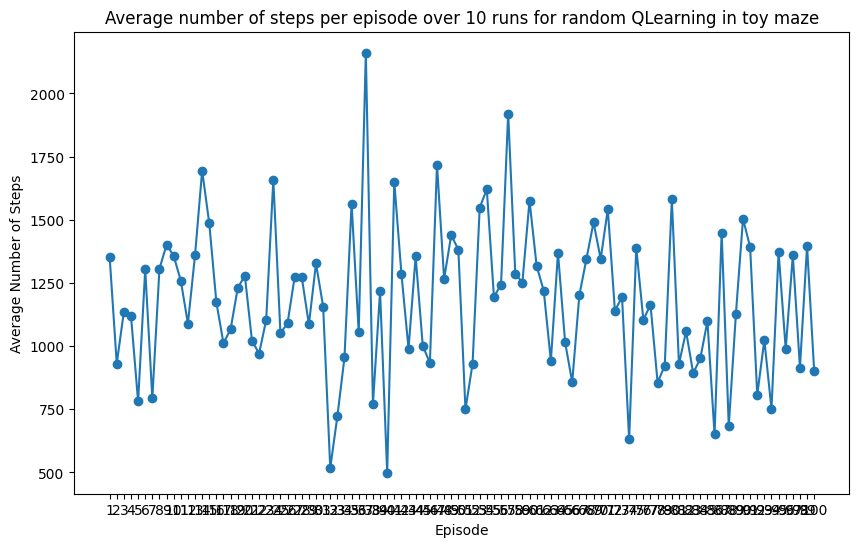

In [205]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the toy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="toy",
    n_episodes=100,
    exploration_strategy_name="random",
    learner_name="QLearning",
    max_steps_per_episode=3000,
 )

Average 10 runs, QLearning, Random strategy (Easy Maze):

Run 1/10 with random seed 1
Run 2/10 with random seed 2
Run 3/10 with random seed 3
Run 4/10 with random seed 4
Run 5/10 with random seed 5
Run 6/10 with random seed 6
Run 7/10 with random seed 7
Run 8/10 with random seed 8
Run 9/10 with random seed 9
Run 10/10 with random seed 10
Shortest run has 100 episodes


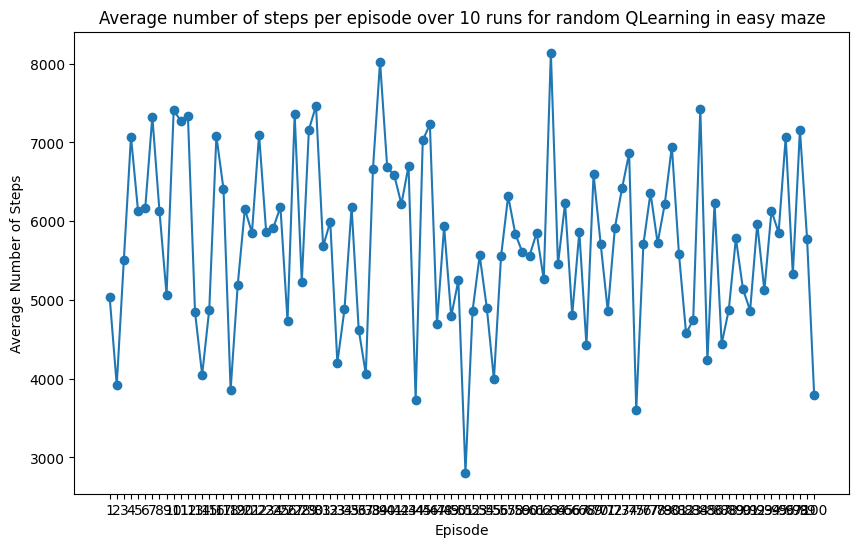

In [206]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=100,
    exploration_strategy_name="random",
    learner_name="QLearning",
    max_steps_per_episode=10000,
 )

Avearge 10 runs, QLearning, Boltzmann, Easy Maze:

Run 1/10 with random seed 1
Run 2/10 with random seed 2
Run 3/10 with random seed 3
Run 4/10 with random seed 4
Run 5/10 with random seed 5
Run 6/10 with random seed 6
Run 7/10 with random seed 7
Run 8/10 with random seed 8
Run 9/10 with random seed 9
Run 10/10 with random seed 10
Shortest run has 100 episodes


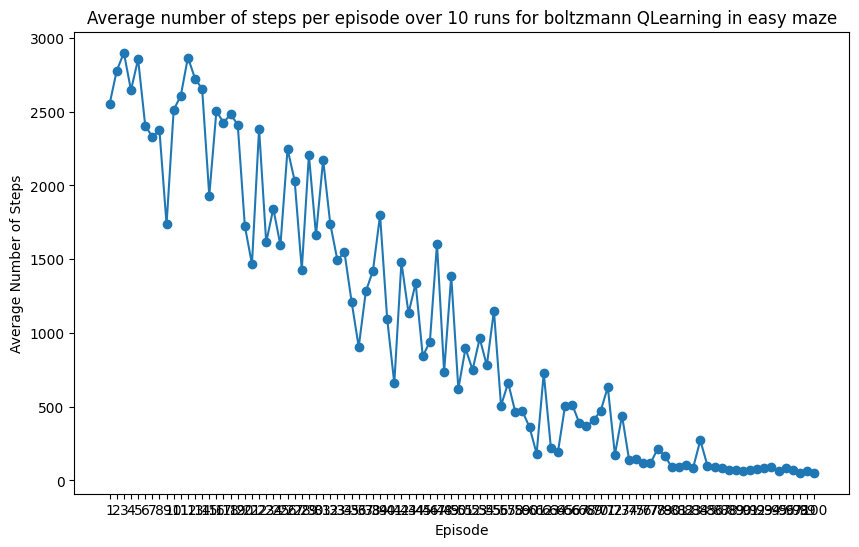

In [207]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=100,
    exploration_strategy_name="boltzmann",
    learner_name="QLearning",
    max_steps_per_episode=3000,
 )

Average 10 runs, QLearning, Greedy, Easy Maze:

Run 1/10 with random seed 1
Run 2/10 with random seed 2
Run 3/10 with random seed 3
Run 4/10 with random seed 4
Run 5/10 with random seed 5
Run 6/10 with random seed 6
Run 7/10 with random seed 7
Run 8/10 with random seed 8
Run 9/10 with random seed 9
Run 10/10 with random seed 10
Shortest run has 100 episodes


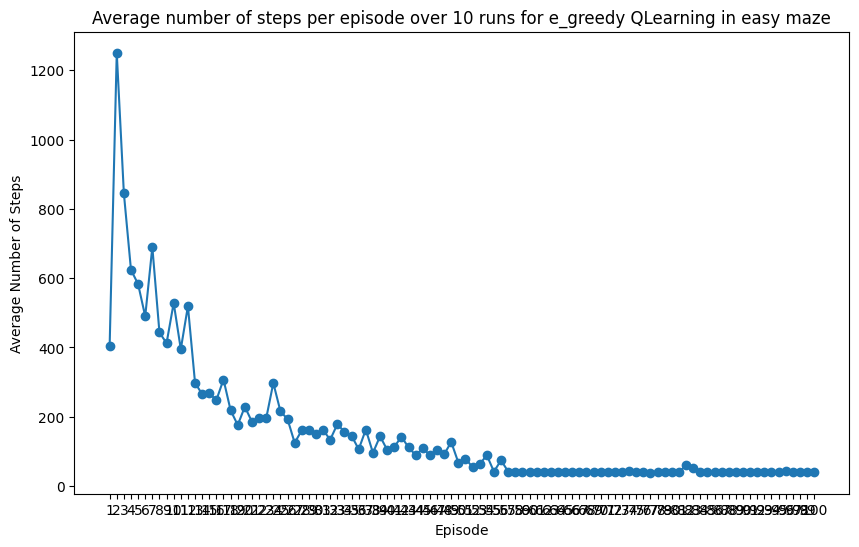

In [213]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=100,
    exploration_strategy_name="e_greedy",
    learner_name="QLearning",
    max_steps_per_episode=10000,
 )

Average 10 runs, SARSA, Random Strategy, Easy Maze: 

Run 1/10 with random seed 1
Run 2/10 with random seed 2
Run 3/10 with random seed 3
Run 4/10 with random seed 4
Run 5/10 with random seed 5
Run 6/10 with random seed 6
Run 7/10 with random seed 7
Run 8/10 with random seed 8
Run 9/10 with random seed 9
Run 10/10 with random seed 10
Shortest run has 100 episodes


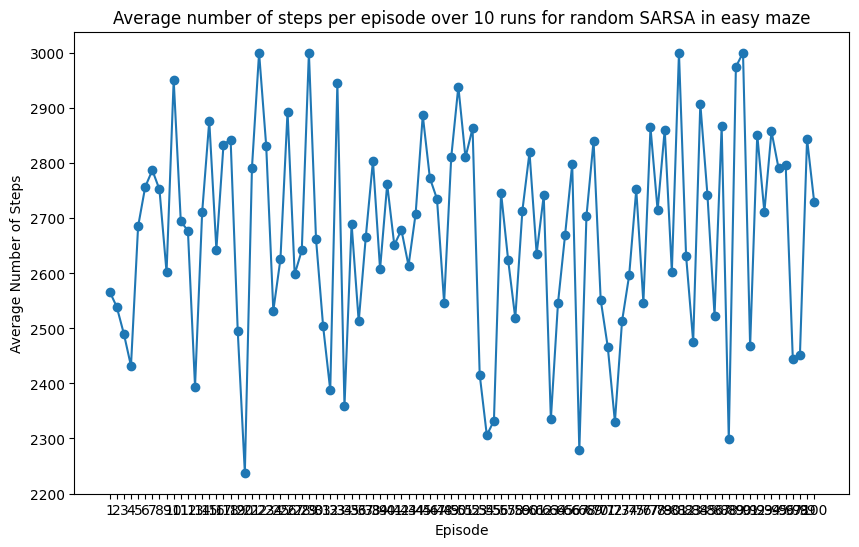

In [214]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=100,
    exploration_strategy_name="random",
    learner_name="SARSA",
    max_steps_per_episode=3000,
)

Average 10 runs, SARSA, Boltzmann, Easy Maze:

Run 1/10 with random seed 1
Run 2/10 with random seed 2
Run 3/10 with random seed 3
Run 4/10 with random seed 4
Run 5/10 with random seed 5
Run 6/10 with random seed 6
Run 7/10 with random seed 7
Run 8/10 with random seed 8
Run 9/10 with random seed 9
Run 10/10 with random seed 10
Shortest run has 100 episodes


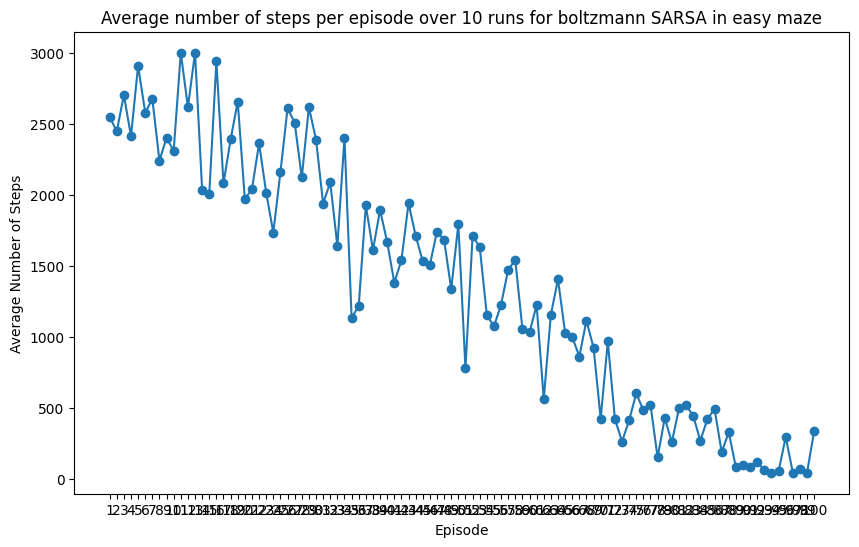

In [216]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=100,
    exploration_strategy_name="boltzmann",
    learner_name="SARSA",
    max_steps_per_episode=3000,
 )

Average 10 runs, SARSA, Greedy, Easy Maze:

Run 1/10 with random seed 1
Run 2/10 with random seed 2
Run 3/10 with random seed 3
Run 4/10 with random seed 4
Run 5/10 with random seed 5
Run 6/10 with random seed 6
Run 7/10 with random seed 7
Run 8/10 with random seed 8
Run 9/10 with random seed 9
Run 10/10 with random seed 10
Shortest run has 100 episodes


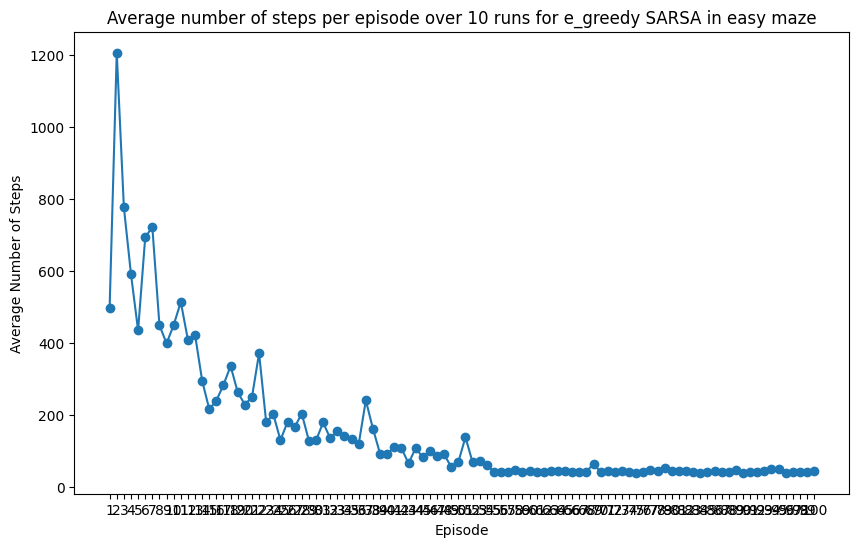

In [217]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=100,
    exploration_strategy_name="e_greedy",
    learner_name="SARSA",
    max_steps_per_episode=3000,
 )

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 7

There are differences between agents trained using QLearning and SARSA. QLearning seems to achieve solutions slightly faster than 

In [220]:
def compare_learners_by_strategy(
    runs_number: int,
    random_seeds: List[int],
    maze_name: str,
    n_episodes: int,
    exploration_strategies: List[str],
    max_steps_per_episode: int
    ):
    """Plot QLearning vs SARSA for each exploration strategy."""
    for strategy in exploration_strategies:
        avg_q = average_steps_per_episode(
            runs_number,
            random_seeds,
            maze_name,
            n_episodes,
            strategy,
            learner_name="QLearning",
            max_steps_per_episode=max_steps_per_episode,
        )
        avg_s = average_steps_per_episode(
            runs_number,
            random_seeds,
            maze_name,
            n_episodes,
            strategy,
            learner_name="SARSA",
            max_steps_per_episode=max_steps_per_episode,
        )

        shortest_len = min(len(avg_q), len(avg_s))
        avg_q = avg_q[:shortest_len]
        avg_s = avg_s[:shortest_len]
        episodes = np.arange(1, shortest_len + 1, 1)

        plt.figure(figsize=(10, 6))
        plt.plot(episodes, avg_q, marker="o", label="QLearning")
        plt.plot(episodes, avg_s, marker="o", label="SARSA")
        plt.title(f"Easy maze: {strategy} exploration")
        plt.xlabel("Episode")
        plt.ylabel("Average Steps")
        plt.legend()
        plt.show()



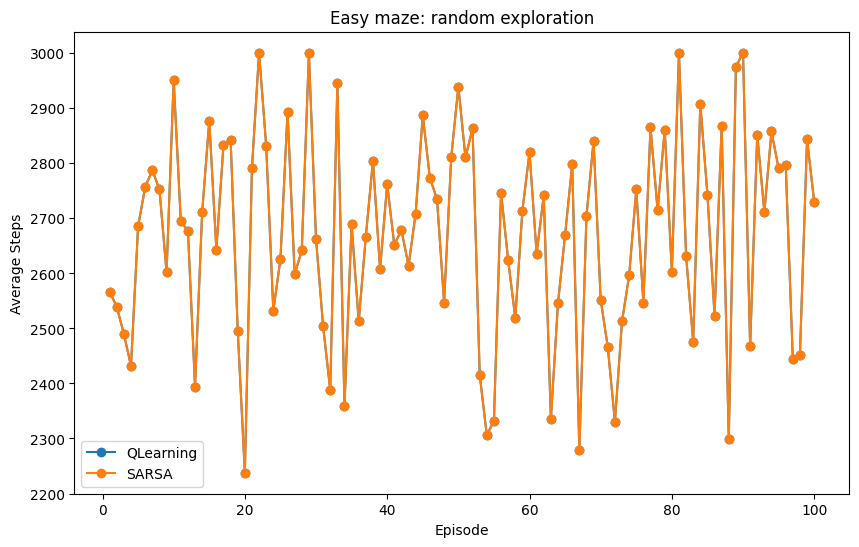

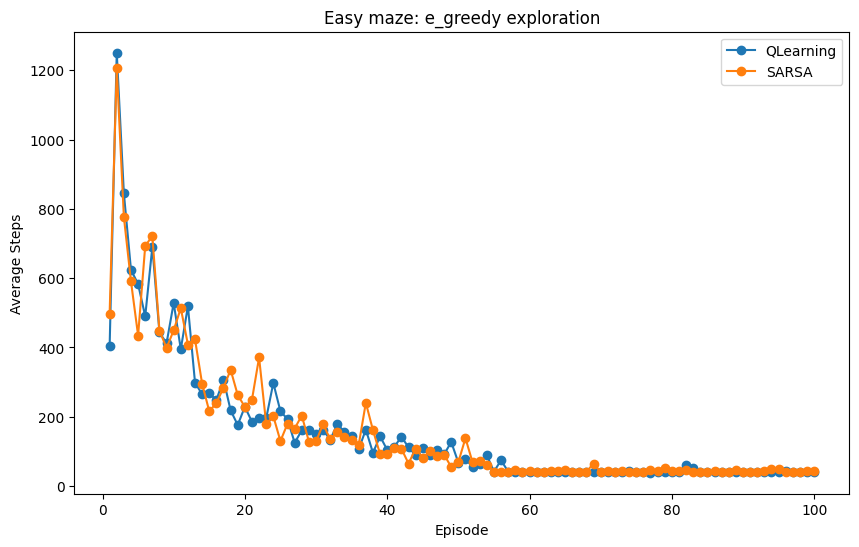

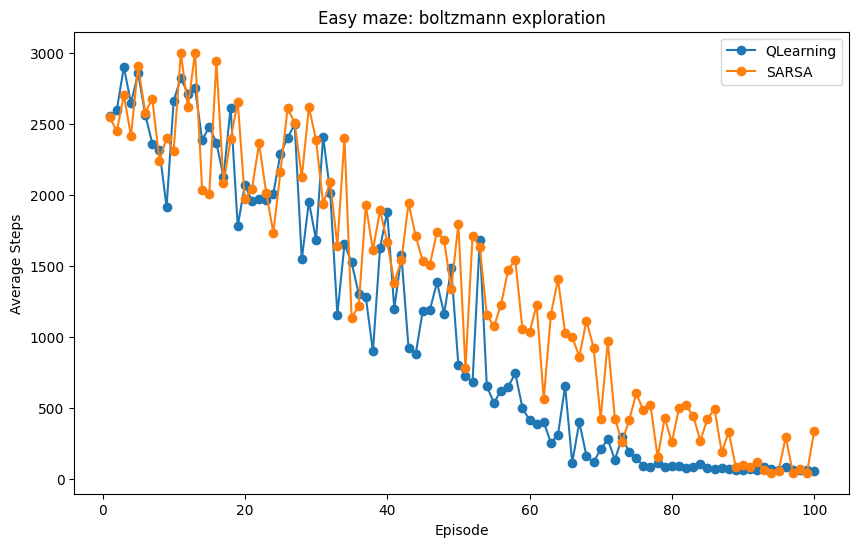

In [221]:
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
compare_learners_by_strategy(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=100,
    exploration_strategies=["random", "e_greedy", "boltzmann"],
    max_steps_per_episode=3000,
 )

### 2.2 Optimization
#### Question 8

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 9

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 10

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 11

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 12

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 18

<div style="background-color:#f1be3e">

_Write your answer here._

#### Question 19

<div style="background-color:#f1be3e">

_Write your answer here._

### 3.2 Pen and Paper
#### Question 20

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 21

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

#### Question 22

<div style="background-color:#f1be3e">

_Write your answer here. You can also choose to simply include a photo of your solution._

### 3.3 Division of Work

#### Question 23

<div style="background-color:#f1be3e">


|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div style="background-color:#f1be3e">

**If you made use of any non-course resources, cite them below.**